<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/L1-L2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Features:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Target:
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

Dataset shape: (20640, 8)

LASSO / L1
MSE : 0.615
RMSE: 0.784
R²  : 0.531

RIDGE / L2
MSE : 0.556
RMSE: 0.745
R²  : 0.576

Coefficients:
      Feature  L1_Lasso  L2_Ridge
0      MedInc     0.742     0.854
1    HouseAge     0.140     0.123
2    AveRooms    -0.000    -0.292
3   AveBedrms     0.000     0.337
4  Population     0.000    -0.002
5  

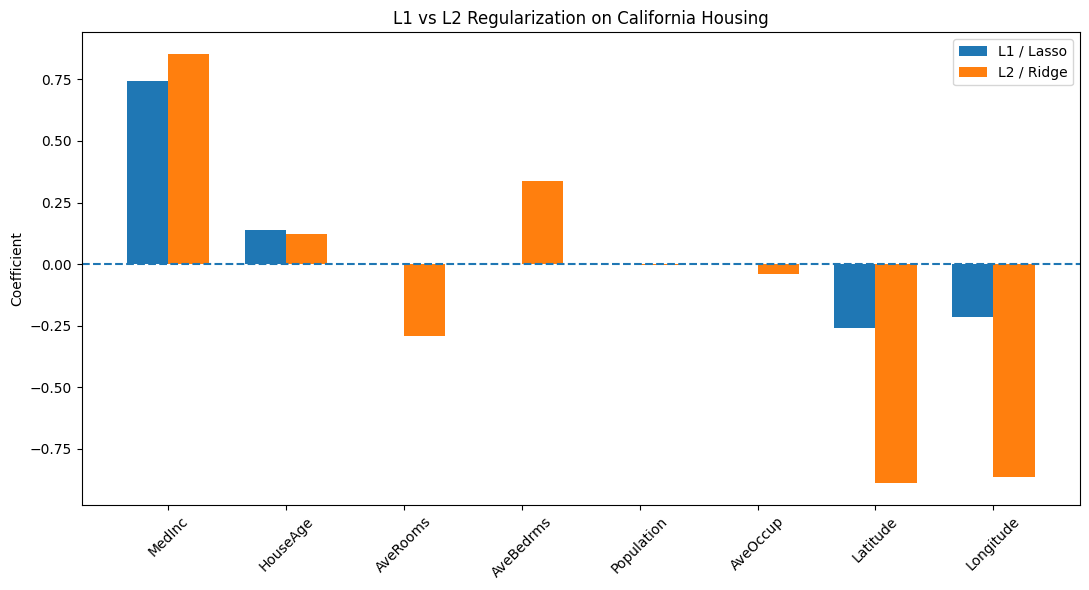

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# --------------------------------------------------
# 1. Load real California Housing dataset
# --------------------------------------------------

housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

print("\nDataset shape:", X.shape)


# --------------------------------------------------
# 2. Train / test split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# --------------------------------------------------
# 3. Standardize features
# --------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --------------------------------------------------
# 4. L1 Regularization: Lasso
# --------------------------------------------------

lasso = Lasso(
    alpha=0.05,
    max_iter=10000
)

lasso.fit(
    X_train_scaled,
    y_train
)

lasso_predictions = lasso.predict(
    X_test_scaled
)


# --------------------------------------------------
# 5. L2 Regularization: Ridge
# --------------------------------------------------

ridge = Ridge(
    alpha=10
)

ridge.fit(
    X_train_scaled,
    y_train
)

ridge_predictions = ridge.predict(
    X_test_scaled
)


# --------------------------------------------------
# 6. Evaluate both
# --------------------------------------------------

lasso_mse = mean_squared_error(
    y_test,
    lasso_predictions
)

ridge_mse = mean_squared_error(
    y_test,
    ridge_predictions
)

lasso_rmse = np.sqrt(lasso_mse)
ridge_rmse = np.sqrt(ridge_mse)

lasso_r2 = r2_score(
    y_test,
    lasso_predictions
)

ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)

print("\nLASSO / L1")
print("MSE :", round(lasso_mse, 3))
print("RMSE:", round(lasso_rmse, 3))
print("R²  :", round(lasso_r2, 3))

print("\nRIDGE / L2")
print("MSE :", round(ridge_mse, 3))
print("RMSE:", round(ridge_rmse, 3))
print("R²  :", round(ridge_r2, 3))


# --------------------------------------------------
# 7. Compare coefficients
# --------------------------------------------------

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "L1_Lasso": lasso.coef_,
    "L2_Ridge": ridge.coef_
})

print("\nCoefficients:")
print(coefficients.round(3))


# --------------------------------------------------
# 8. Count zero coefficients
# --------------------------------------------------

lasso_zero_count = np.sum(
    np.isclose(
        lasso.coef_,
        0
    )
)

ridge_zero_count = np.sum(
    np.isclose(
        ridge.coef_,
        0
    )
)

print(
    "\nLasso zero coefficients:",
    lasso_zero_count
)

print(
    "Ridge zero coefficients:",
    ridge_zero_count
)


# --------------------------------------------------
# 9. Visualize coefficients
# --------------------------------------------------

x = np.arange(
    len(X.columns)
)

width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    lasso.coef_,
    width,
    label="L1 / Lasso"
)

plt.bar(
    x + width / 2,
    ridge.coef_,
    width,
    label="L2 / Ridge"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xticks(
    x,
    X.columns,
    rotation=45
)

plt.ylabel("Coefficient")

plt.title(
    "L1 vs L2 Regularization on California Housing"
)

plt.legend()
plt.tight_layout()

plt.show()